# DDPM using the Diffusers library

Now that we've seen how to build a custom DDPM, we'll see how we can do it faster using the `Diffuser` lib

In [1]:
import numpy as np
import torch
import torchvision
import torch.nn.functional as F
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from PIL import Image
from tqdm import tqdm
# Those imports will allow us to build the model and the scheduler in just a few lines of code
from diffusers import DDPMScheduler, UNet2DModel

In [2]:
# Set up your GPU (or cpu if the CUDA/ROCM gods aren't in a good mood today)
# From IAO4 tutorial on GANs
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

#Additional Info when using cuda
if device == 'cuda':
    print('Number of GPU(s):', torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using cuda device
Number of GPU(s): 1
NVIDIA GeForce GTX 1650 with Max-Q Design
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
# Load the MNIST dataset just like before


data_transform = torchvision.transforms.Compose(
[torchvision.transforms.ToTensor(), torchvision.transforms.Normalize((0.5,), (0.5,))]
)

dataset = torchvision.datasets.FashionMNIST(
    root="fashionmnist/", train=True, download=True, transform=data_transform
)



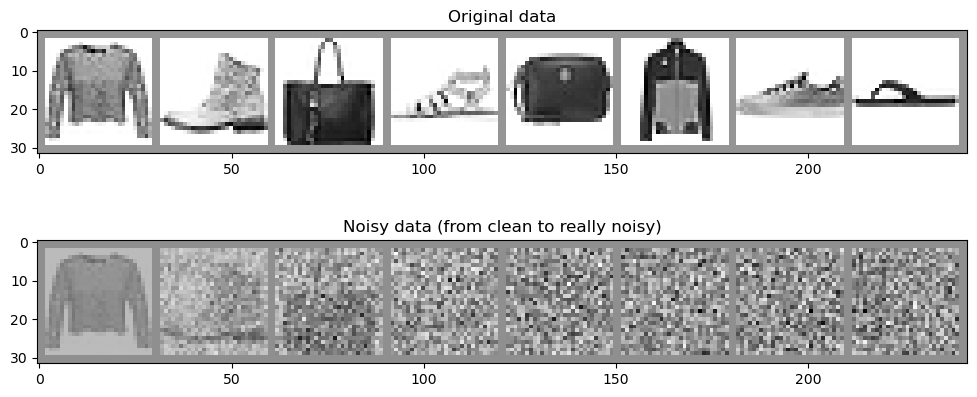

In [19]:
# Prepare the scheduler 
## We'll reuse some code of the TP to show that the effect is similar to what we've built a few days ago
# Iterate on the data loader to generate a batch of images
sample_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
sample, _= next(iter(sample_dataloader))

# create a vector with the same number of item as the samples (e.g. 8), gradually increasing from 0 to 1
timesteps = 1000
t = torch.linspace(0, timesteps-1, sample.shape[0], dtype=torch.int)  

noise_scheduler = DDPMScheduler(num_train_timesteps=timesteps, beta_schedule='linear')

noise = torch.randn_like(sample)
noisy_sample = noise_scheduler.add_noise(sample, noise, t)

# Display the samples and their reference 
ig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title("Original data")
axs[0].imshow(torchvision.utils.make_grid(sample)[0], cmap="Greys")
# Plotting the noised version
axs[1].set_title("Noisy data (from clean to really noisy)")
axs[1].imshow(torchvision.utils.make_grid(noisy_sample)[0], cmap="Greys")


The noisy imagesare similar (with some variations in term of noise intensity) but will produce almost the same kind of results

The `DDPMScheduler` class implement a whole lot of additionnal parameters you can play with (see [the documentation](https://huggingface.co/docs/diffusers/api/schedulers/ddpm) for more info). For instance you can play with the scheduling of the beta parameter which is linear in the DDPM paper but has seen some changes in later works.

In [7]:
# Initiallise the DDPM-Unet based on the model from the TP 
# You can try to make it bigger if your hardware supports it
net = UNet2DModel(

    
    sample_size=sample.shape[3],  
    in_channels=sample.shape[1],  
    out_channels=sample.shape[1],  
    
    layers_per_block=2, 
    
    block_out_channels=(32, 64, 64),
    down_block_types=(
        "DownBlock2D",  
        "DownBlock2D",
        "DownBlock2D",  
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D", 
        "AttnUpBlock2D",# Resnet block with upsampling AND attention
    )
)

Again, the `UNet2DModel` class has also a lot more parameters and configuration options to suit your needs. Here its only used to mimic the network used in the TD but you can add a lot more layers if needed, resnet blocks in the layers or attention layers in the downscaling steps. See the [official doc](https://huggingface.co/docs/diffusers/api/models/unet2d) for more info.

In [9]:
# Setting up the training loop
losses = []
num_epoch = 1
batch_size = 8

opt = torch.optim.Adam(net.parameters(), lr=1e-3) # Change at your own risk ;) 
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True) 

for epoch in range(num_epoch):
    for x, y in tqdm(train_dataloader):
        # Sample noise to add to the images
        noise = torch.randn(x.shape).to(x.device)
        batch_size = x.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (batch_size,), device=x.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_x = noise_scheduler.add_noise(x, noise, timesteps)

        # Get the model prediction
        noise_pred = net(noisy_x, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        # Update the model parameters with the optimizer
        opt.step()
        opt.zero_grad()

    

100%|██████████| 7500/7500 [43:39<00:00,  2.86it/s]  


(0.0, 0.5)

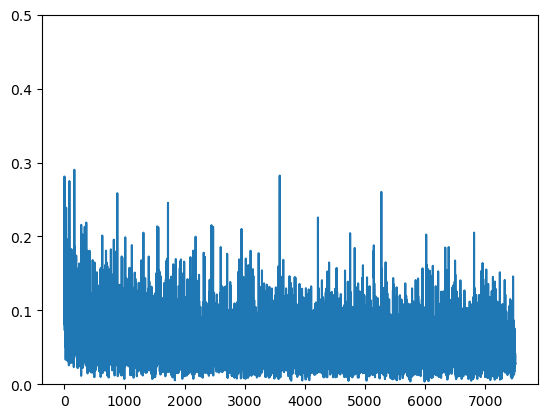

In [10]:
# Display the training loss
plt.plot(losses)
plt.ylim(0, 0.5) # Change the upper bound if needed to see the loss variations more clearly 

Image 1/8


1000it [00:24, 40.53it/s]


Image 2/8


1000it [00:28, 35.07it/s]


Image 3/8


...

1000it [00:28, 34.86it/s]


Image 7/8


1000it [00:24, 41.39it/s]


Image 8/8


1000it [00:24, 40.23it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.0216947..3.7933037].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


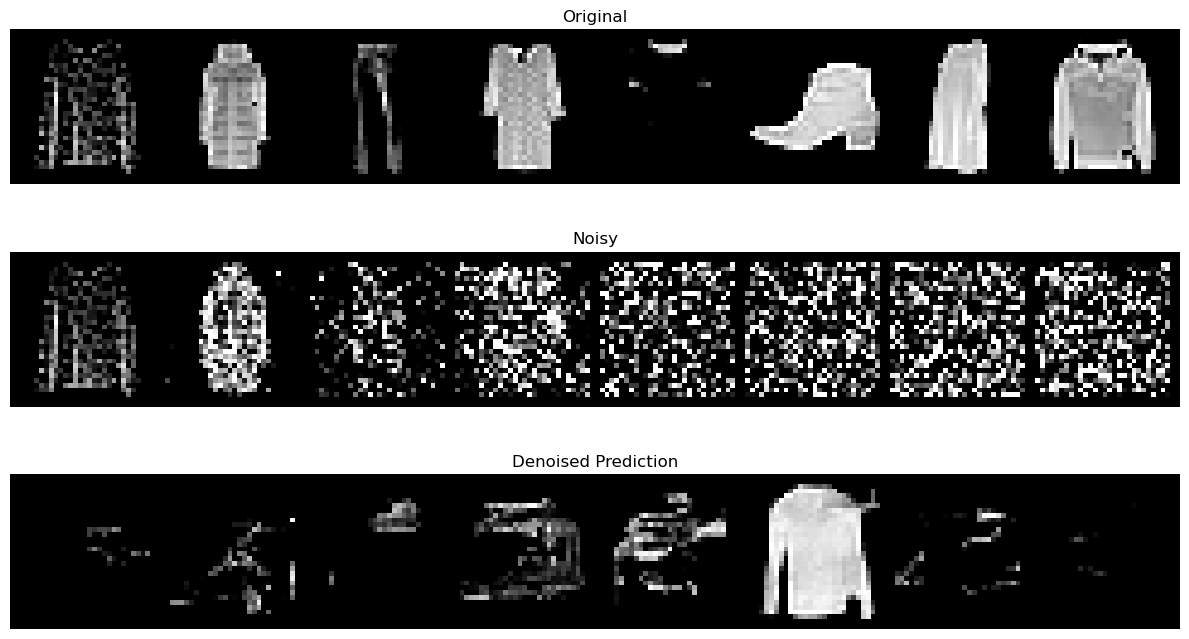

In [32]:
# Suppose que tu as déjà un dataset et un modèle entraîné nommé `net`
sample_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
sample, y = next(iter(sample_dataloader))  # Shape: [8, 1, 28, 28]

timesteps = 1000
t = torch.linspace(0, timesteps-1, sample.shape[0], dtype=torch.int)  

# Assure-toi que tout est sur le même device
device = sample.device
sample = sample.to(device)
t = t.to(device)

# Scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=timesteps, beta_schedule='linear')

# Ajouter du bruit
noise = torch.randn_like(sample)
noisy_sample = noise_scheduler.add_noise(sample, noise, t)

# Générer les prédictions
preds = torch.empty_like(sample)

net.eval()
for i in range(sample.size(0)):
    print(f"Image {i+1}/{sample.size(0)}")
    noisy = noisy_sample[i].unsqueeze(0)  # Shape: [1, 1, 28, 28]
    for j, tu in tqdm(enumerate(noise_scheduler.timesteps)):

        # Run the inference
        with torch.no_grad():
            residual = net(noisy, tu, return_dict=False)[0]

        # Iterate on the sample to reconstruct the image
        noisy = noise_scheduler.step(residual, tu, noisy).prev_sample
    preds[i] = noisy.squeeze(0)  # Shape: [1, 28, 28]

# Affichage
def show_tensor_image(ax, tensor, title=""):
    image = torchvision.utils.make_grid(tensor, nrow=8).permute(1, 2, 0).squeeze()
    ax.set_title(title)
    ax.axis("off")
    ax.imshow(image.cpu().numpy(), cmap="gray")

fig, axs = plt.subplots(3, 1, figsize=(12, 7))
show_tensor_image(axs[0], sample, "Original")
show_tensor_image(axs[1], noisy_sample, "Noisy")
show_tensor_image(axs[2], preds, "Denoised Prediction")
plt.tight_layout()
plt.show()

1000it [00:49, 20.10it/s]


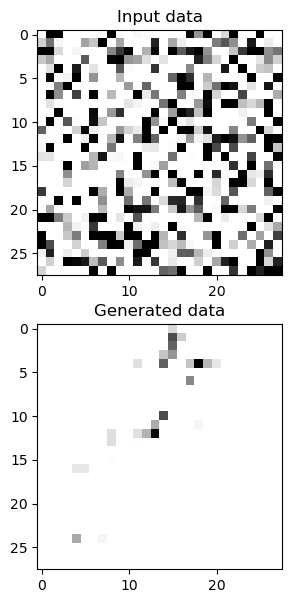

In [30]:
# Create random images 
sample = torch.randn(1, 1, 28, 28)

fig, axs = plt.subplots(2, 1, figsize=(12, 7))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(sample)[0].clip(0, 1), cmap="Greys")

for i, t in tqdm(enumerate(noise_scheduler.timesteps)):

    # Run the inference
    with torch.no_grad():
        residual = net(sample, t).sample

    # Iterate on the sample to reconstruct the image
    sample = noise_scheduler.step(residual, t, sample).prev_sample

# Display your results

axs[1].set_title("Generated data")
axs[1].imshow(torchvision.utils.make_grid(sample)[0].clip(0, 1), cmap="Greys")

Again, the resulting images can be quite good if we scale the model a bit more and let it learn for longer. But we can already see that it works well ! 

# Report :

Select at least one of your implementation of the DDPM Unet using the SIMPLIFIED scheduling (which is almost equivalent to a VAE) and train it for a few epochs (depending on the hardware you have at your disposal) on the dataset of your choice.

Using either the solution in the `DDPM_main` notebook or the `DDPM_diffusers`implementation here, train a "reference" DDPM for the same number of epochs (and denoising steps).  Try to keep the training time under 15min for each model, a full training isn't the goal here.

Try to not reuse MNIST, there is other options readily available through the `torchvision.datasets` library. Such as : 
- `FashionMNIST`
- `FGVCAircraft`
- `EuroSAT`
- `KMNIST` MNIST but with Kuzushiji (japanese) characters (same number of items as MNIST)
- etc...
  
If the size of the images are too big, you can add `transforms.Resize((image_size, image_size))` to your data transforms to rescale it to a smaller size and still be able to experiment with something different than MNIST.

Another warning, some of those datasets contains RGB images, you'll have to adapt some parameters to load them properly in your models 

Once both are trained, write a small experimental report which explain your choice of models, and if applicable, any modification you've included compared to the solutions.
It should also include : 
- A figure with both loss metrics evolution during training,
- Two sets of reconstructed image samples, one for each of your models, with different noise levels (as we've done during the TP)
- Two sets of images built from pure noise, one for each of your models. WARNING : You might not be able to generate very good looking examples with your hardware if you were only able to train your models for only 1 or 2 epochs but it will be enough to make a quick analysis.
- A qualitative analysis of the images you have generated in a few lines.
- Your opinion on the best models depending on your situation (available compute power, image quality, training time...)

Keep it concise, 2 page maximum. 